### Ejercicio regresión polinomial

#### Utilizando los modelos de regresión vistos hasta ahora, genera el modelo que mejor se adapte a los datos adjuntos. La pregunta objetivo es: ¿Cuál es la longitud del pez bluegill en función de su edad?


#### En 1981, 78 diferentes peces bluegills fueron aleatoriamente caracterizados según su longitud y edad de un lago de Minnesota. Los investigadores midieron y grabaron los datos que se adjuntan. 

In [6]:
!pip install plotly
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

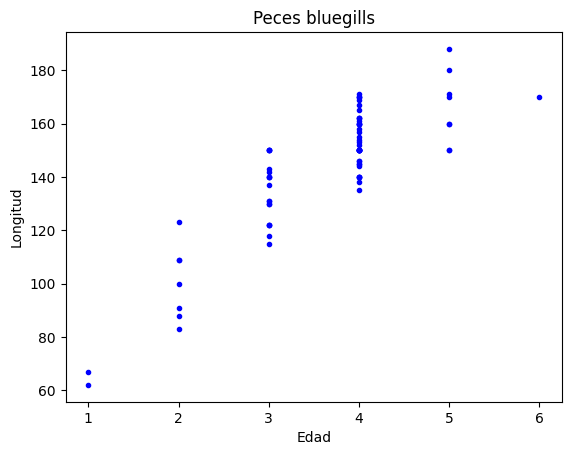

In [22]:
#Cargamos los datos de entrada
df = pd.read_csv("Datos mojarra americana.txt", sep= '\t', header = 0)
# Acceder a las columnas 'X' y 'Y'
X = df['age'].values.reshape(-1,1)  # Columna X
Y = df['length'].values.reshape(-1,1) # Columna Y

# Crear la gráfica
plt.plot(X, Y, 'b.')  # Gráfico de puntos (scatter plot) con color azul
plt.xlabel('Edad')  # Etiqueta del eje X
plt.ylabel('Longitud')  # Etiqueta del eje Y
plt.title('Peces bluegills')  # Título de la gráfica
plt.show()  # Mostrar la gráfica

In [23]:
#Un 80% de los datos es de entrenamiento y el 20% restante de test
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [33]:
#Aplicamos regresión polinomial de 2º grado
poly = PolynomialFeatures(degree=3, include_bias=True)
x_train_trans = poly.fit_transform(x_train)
x_test_trans = poly.transform(x_test)
#include bias parameter
lr = LinearRegression()
lr.fit(x_train_trans, y_train)
y_pred = lr.predict(x_test_trans)

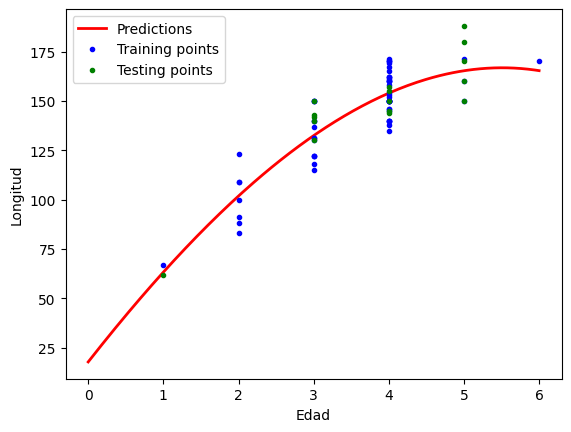

In [35]:
X_new = np.linspace(0, 6, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(x_train, y_train, "b.",label='Training points')
plt.plot(x_test, y_test, "g.",label='Testing points')
plt.xlabel("Edad")
plt.ylabel("Longitud")
plt.legend()
plt.show()